# LeNet-5: A Classic Convolutional Neural Network

This notebook implements and explores **LeNet-5**, one of the earliest and most influential Convolutional Neural Network (CNN) architectures.

We will use **PyTorch** to build, train, and evaluate a LeNet-5-inspired model on the **MNIST handwritten digit dataset**.

### Notebook Contents

1. Introduction
2. What is LeNet-5?
3. LeNet-5 Architecture
4. Dataset
5. Data Preprocessing
6. Building LeNet-5 with PyTorch
7. Understanding Each Layer
8. Training the Model
9. Evaluating the Model
10. Results
11. What We Learned

## 1. Introduction

Convolutional Neural Networks (CNNs) are a class of deep learning models designed especially for working with images.

Before modern architectures such as AlexNet, VGGNet, and GoogLeNet became popular, **LeNet-5** demonstrated that neural networks could effectively learn visual patterns directly from images.

In this notebook, we will:

- Understand the idea behind LeNet-5
- Explore its architecture
- Prepare the MNIST dataset
- Implement the architecture using PyTorch
- Train the model
- Evaluate its performance
- Analyze the results

The goal is not only to train the model, but also to understand **why each layer exists and how the image changes as it passes through the network**.

## 2. What is LeNet-5?

**LeNet-5** was introduced by Yann LeCun and his colleagues in 1998 for handwritten digit recognition.

It is one of the foundational CNN architectures and played an important role in demonstrating the effectiveness of convolutional neural networks for image classification.

### Key ideas used in LeNet-5

- Convolutional layers learn visual features
- Pooling/subsampling reduces spatial dimensions
- Non-linear activation functions allow the network to learn complex patterns
- Fully connected layers perform classification
- The network learns features automatically from images instead of relying on manually designed features

The original LeNet-5 architecture was designed for **32 × 32 grayscale images** and consisted of convolution, subsampling, and fully connected layers.

Our implementation follows the main structure of LeNet-5 while using modern PyTorch layers and training practices.

## 3. LeNet-5 Architecture

The main flow of our implementation is:

**Input → C1 → S2 → C3 → S4 → C5 → F6 → Output**

Where:

- **C1** → Convolutional layer
- **S2** → Average pooling layer
- **C3** → Convolutional layer
- **S4** → Average pooling layer
- **C5** → Fully connected layer
- **F6** → Fully connected layer
- **Output** → 10 digit classes

### Architecture Flow

```text
Input Image
32 × 32 × 1
     ↓
Conv2D
6 × 28 × 28
     ↓
Tanh
     ↓
Average Pooling
6 × 14 × 14
     ↓
Conv2D
16 × 10 × 10
     ↓
Tanh
     ↓
Average Pooling
16 × 5 × 5
     ↓
Flatten
400 features
     ↓
Linear
120
     ↓
Tanh
     ↓
Linear
84
     ↓
Tanh
     ↓
Linear
10
     ↓
Output

In [3]:
# Import required libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

# Check PyTorch version
print("PyTorch version:", torch.__version__)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Using device: cuda
GPU: Tesla T4


## 4. Dataset

For this implementation, we will use the **MNIST handwritten digit dataset**.

MNIST contains grayscale images of handwritten digits from **0 to 9**.

### Dataset Statistics

- **Training images:** 60,000
- **Test images:** 10,000
- **Image type:** Grayscale
- **Original image size:** 28 × 28 pixels
- **Number of classes:** 10
- **Classes:** 0, 1, 2, 3, 4, 5, 6, 7, 8, 9

LeNet-5 was originally designed for 32 × 32 pixel input images. Therefore, we will resize the MNIST images from **28 × 28 to 32 × 32** before feeding them into the model.

In [4]:
# Load the MNIST dataset

raw_transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=raw_transform
)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=raw_transform
)

print("Training samples:", len(mnist_train))
print("Test samples:", len(mnist_test))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.86MB/s]

Training samples: 60000
Test samples: 10000


### Visualizing MNIST Samples

Before preprocessing the data, let's visualize a few examples from the dataset.

This helps us understand what the input images actually look like.

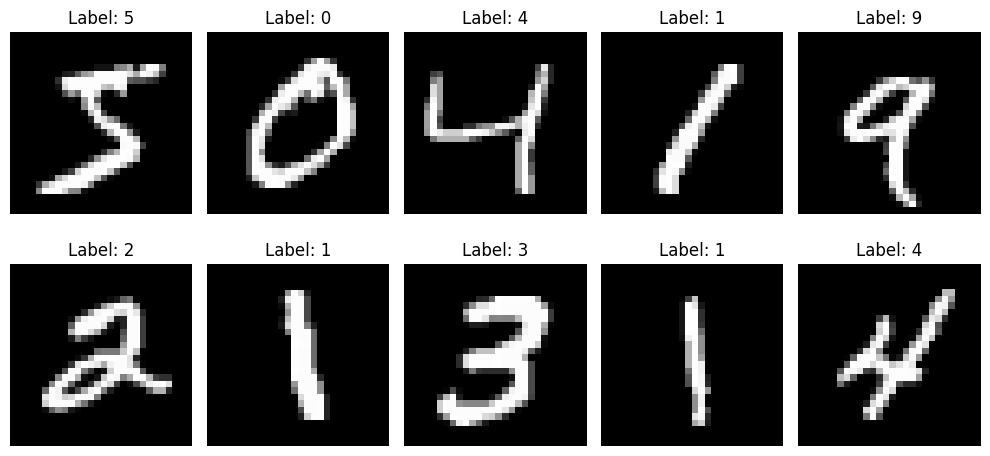

In [5]:
# Display sample images from MNIST

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = mnist_train[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

The MNIST images are originally **28 × 28 pixels**, while our LeNet-5 implementation expects **32 × 32 pixel** inputs.

We will apply the following preprocessing steps:

1. **Resize** the image from 28 × 28 to 32 × 32
2. **Convert** the image into a PyTorch tensor
3. **Normalize** the pixel values
4. **Split** the training dataset into training and validation sets

### Normalization

For MNIST, we use:

- Mean = `0.1307`
- Standard deviation = `0.3081`

Normalization helps keep the input values in a suitable range and can make neural network training more stable.

### Dataset Split

We will use:

- **50,000 images** → Training
- **10,000 images** → Validation
- **10,000 images** → Test

In [6]:
# Define preprocessing transformations

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the preprocessed MNIST datasets

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Split training data into training and validation sets

train_dataset, val_dataset = random_split(
    train_data,
    [50000, 10000]
)

# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_data)}")

Train: 50000
Validation: 10000
Test: 10000


### Checking the Data Shape

Let's inspect one batch of images to verify that the preprocessing produced the expected dimensions.

The expected shape is:

```text
Batch Size × Channels × Height × Width

64 × 1 × 32 × 32

In [8]:
# Check the shape of one batch

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 32, 32])
Label batch shape: torch.Size([64])


## 6. Building LeNet-5 with PyTorch

Now that the MNIST dataset has been prepared, we can build the LeNet-5-inspired CNN using PyTorch.

The model is divided into two main blocks:

### 1. Feature Extraction Block

This block contains:

- Convolutional layers
- Tanh activation functions
- Average pooling layers

Its job is to learn useful visual features from the input image.

### 2. Classification Block

This block contains:

- Flattening
- Fully connected (Linear) layers
- Tanh activation functions
- Final output layer

Its job is to use the extracted features to classify the image into one of the 10 digit classes.

The architecture implemented below follows the main structure of LeNet-5 while using modern PyTorch layers and training practices.

In [9]:
# Define the LeNet-5 model

class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()

        # Feature extraction block
        self.feature = nn.Sequential(

            # C1 - First convolutional layer
            # Input:  1 × 32 × 32
            # Output: 6 × 28 × 28
            nn.Conv2d(
                in_channels=1,
                out_channels=6,
                kernel_size=5,
                stride=1
            ),

            nn.Tanh(),

            # S2 - Average pooling
            # 28 × 28 → 14 × 14
            nn.AvgPool2d(
                kernel_size=2,
                stride=2
            ),

            # C3 - Second convolutional layer
            # Input:  6 × 14 × 14
            # Output: 16 × 10 × 10
            nn.Conv2d(
                in_channels=6,
                out_channels=16,
                kernel_size=5,
                stride=1
            ),

            nn.Tanh(),

            # S4 - Average pooling
            # 10 × 10 → 5 × 5
            nn.AvgPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Classification block
        self.classifier = nn.Sequential(

            # Flatten: 16 × 5 × 5 = 400
            nn.Flatten(),

            # C5
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),

            # F6
            nn.Linear(120, 84),
            nn.Tanh(),

            # Output layer
            # 10 outputs = digits 0-9
            nn.Linear(84, 10)
        )

    def forward(self, x):

        # Feature extraction
        x = self.feature(x)

        # Classification
        x = self.classifier(x)

        return x

### Create the Model

Now we create an instance of `LeNet5` and move it to the selected device.

Since our Colab runtime is using a **Tesla T4 GPU**, the model will be moved to the GPU using `.to(device)`.

In [10]:
# Create the model and move it to the selected device

model = LeNet5().to(device)

print(model)

LeNet5(
  (feature): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): Tanh()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Tanh()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)


## 7. Understanding Each Layer

Let's trace the image through the network to understand how its dimensions change.

### Input

The input image has:

```text
1 × 32 × 32

In [12]:
x = torch.randn(1, 1, 32, 32).to(device)

print("Input:              ", x.shape)

x = model.feature[0](x)
print("After C1:            ", x.shape)

x = model.feature[1](x)
print("After Tanh:          ", x.shape)

x = model.feature[2](x)
print("After S2 Pooling:    ", x.shape)

x = model.feature[3](x)
print("After C3:            ", x.shape)

x = model.feature[4](x)
print("After Tanh:          ", x.shape)

x = model.feature[5](x)
print("After S4 Pooling:    ", x.shape)

x = torch.flatten(x, 1)
print("After Flatten:       ", x.shape)

Input:               torch.Size([1, 1, 32, 32])
After C1:             torch.Size([1, 6, 28, 28])
After Tanh:           torch.Size([1, 6, 28, 28])
After S2 Pooling:     torch.Size([1, 6, 14, 14])
After C3:             torch.Size([1, 16, 10, 10])
After Tanh:           torch.Size([1, 16, 10, 10])
After S4 Pooling:     torch.Size([1, 16, 5, 5])
After Flatten:        torch.Size([1, 400])


### Checking the Final Output

The model should accept a batch of 64 images and produce 10 output values for each image.

Therefore:

```text
Input:
64 × 1 × 32 × 32

Output:
64 × 10

In [13]:
# Check the complete model output

images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input shape :", images.shape)

print("Output shape:", outputs.shape)

Input shape : torch.Size([64, 1, 32, 32])
Output shape: torch.Size([64, 10])


## 8. Training the Model

Now we can train the LeNet-5 model.

We need two important components:

### Loss Function

We use **CrossEntropyLoss** because MNIST is a multi-class classification problem with 10 classes.

The model produces 10 logits for each image, and the loss function compares these logits with the correct digit label.

### Optimizer

We use the **Adam optimizer** with a learning rate of `0.001`.

The optimizer updates the model's weights based on the gradients calculated during backpropagation.

### Training Process

For every batch:

1. Perform a forward pass
2. Calculate the loss
3. Clear previously calculated gradients
4. Perform backpropagation
5. Update the model weights
6. Calculate training accuracy

We will train the model for **10 epochs** and evaluate it on the validation set after each epoch.

In [14]:
# Define loss function and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)

epochs = 10

### Training Step

The `train_step()` function performs one complete pass through the training dataset.

The important part is the learning process:

```text
Images
   ↓
Model
   ↓
Logits
   ↓
Loss
   ↓
Backpropagation
   ↓
Gradients
   ↓
Optimizer
   ↓
Updated Weights

In [15]:
def train_step(model, loader, loss_fn, optimizer, device):

    # Put model into training mode
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:

        # Move data to the selected device
        images = images.to(device)
        labels = labels.to(device)

        # Step 1: Forward pass
        logits = model(images)

        # Step 2: Calculate loss
        loss = loss_fn(logits, labels)

        # Step 3: Clear old gradients
        optimizer.zero_grad()

        # Step 4: Backpropagation
        loss.backward()

        # Step 5: Update model weights
        optimizer.step()

        # Track total loss
        total_loss += loss.item() * images.size(0)

        # Calculate predictions
        predictions = logits.argmax(dim=1)

        # Count correct predictions
        total_correct += (predictions == labels).sum().item()

        # Count total samples
        total_samples += labels.size(0)

    # Calculate average loss and accuracy
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

### Validation Step

During validation, we do **not** update the model's weights.

We only measure how well the current model performs on the validation dataset.

Therefore, we:

- Use `model.eval()` to switch to evaluation mode
- Use `torch.no_grad()` to disable gradient calculation
- Calculate validation loss and accuracy

This allows us to monitor how well the model generalizes to data it did not use for training.

In [16]:
def eval_step(model, loader, loss_fn, device):

    # Put model into evaluation mode
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in loader:

            # Move data to the selected device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(images)

            # Calculate loss
            loss = loss_fn(logits, labels)

            # Track total loss
            total_loss += loss.item() * images.size(0)

            # Calculate predictions
            predictions = logits.argmax(dim=1)

            # Count correct predictions
            total_correct += (predictions == labels).sum().item()

            # Count total samples
            total_samples += labels.size(0)

    # Calculate average loss and accuracy
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

### Training the Model

We will now train LeNet-5 for 10 epochs.

For every epoch, we will record:

- Training loss
- Training accuracy
- Validation loss
- Validation accuracy

These values will later be used to visualize the learning process.

In [17]:
# Store training history

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# Train the model

for epoch in range(epochs):

    train_loss, train_acc = train_step(
        model=model,
        loader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = eval_step(
        model=model,
        loader=val_loader,
        loss_fn=loss_fn,
        device=device
    )

    # Store results
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Display results
    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 0.2583 | Train Acc: 0.9278 | Val Loss: 0.0968 | Val Acc: 0.9717
Epoch [2/10] | Train Loss: 0.0734 | Train Acc: 0.9776 | Val Loss: 0.0664 | Val Acc: 0.9798
Epoch [3/10] | Train Loss: 0.0517 | Train Acc: 0.9839 | Val Loss: 0.0546 | Val Acc: 0.9843
Epoch [4/10] | Train Loss: 0.0401 | Train Acc: 0.9880 | Val Loss: 0.0573 | Val Acc: 0.9832
Epoch [5/10] | Train Loss: 0.0339 | Train Acc: 0.9899 | Val Loss: 0.0514 | Val Acc: 0.9835
Epoch [6/10] | Train Loss: 0.0258 | Train Acc: 0.9920 | Val Loss: 0.0530 | Val Acc: 0.9844
Epoch [7/10] | Train Loss: 0.0232 | Train Acc: 0.9923 | Val Loss: 0.0493 | Val Acc: 0.9861
Epoch [8/10] | Train Loss: 0.0186 | Train Acc: 0.9940 | Val Loss: 0.0518 | Val Acc: 0.9855
Epoch [9/10] | Train Loss: 0.0161 | Train Acc: 0.9949 | Val Loss: 0.0523 | Val Acc: 0.9854
Epoch [10/10] | Train Loss: 0.0156 | Train Acc: 0.9951 | Val Loss: 0.0551 | Val Acc: 0.9850


## 9. Evaluating the Model

After training the LeNet-5 model, we will evaluate it on the **10,000 MNIST test images**.

The test dataset was not used to update the model's weights during training.

Therefore, test performance gives us an estimate of how well the trained model generalizes to completely unseen data.

We will calculate:

- Test Loss
- Test Accuracy

We will also generate predictions that will be used later for visualization and the confusion matrix.

In [18]:
# Evaluate the trained model on the test set

test_loss, test_acc = eval_step(
    model=model,
    loader=test_loader,
    loss_fn=loss_fn,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss: 0.0420
Test Accuracy: 0.9878
Test Accuracy: 98.78%


### Generate Test Predictions

Next, we will generate predictions for all images in the test dataset.

These predictions will allow us to:

- Compare predicted labels with actual labels
- Visualize correctly and incorrectly classified digits
- Create a confusion matrix

In [19]:
# Generate predictions for the entire test dataset

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        # Forward pass
        logits = model(images)

        # Get predicted class
        predictions = logits.argmax(dim=1)

        # Move predictions and labels to CPU
        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Convert lists to NumPy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions shape:", all_predictions.shape)
print("Labels shape:", all_labels.shape)

Predictions shape: (10000,)
Labels shape: (10000,)


## 10. Results

Now that the model has been evaluated, we will analyze its performance visually.

We will examine:

1. Training and validation loss
2. Training and validation accuracy
3. Model predictions
4. Confusion matrix

These visualizations help us understand not only how accurate the model is, but also how it learned and where it makes mistakes.

### Training and Validation Loss

The loss curves show how the model's prediction error changed during training.

Ideally:

- Training loss should decrease
- Validation loss should generally decrease
- A large difference between training and validation loss can indicate overfitting

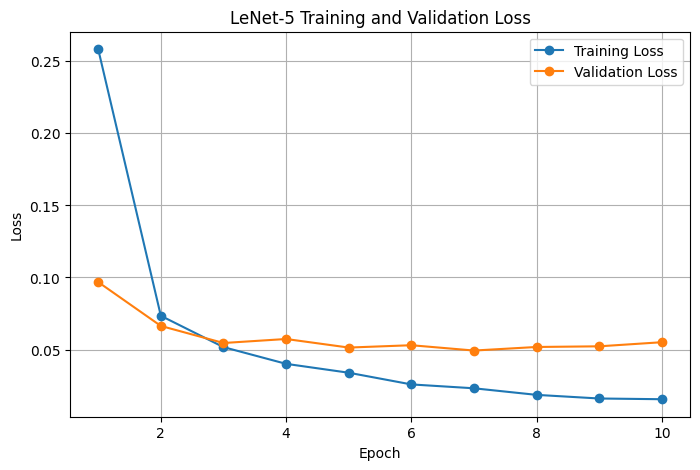

In [20]:
# Plot training and validation loss

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LeNet-5 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Training and Validation Accuracy

The accuracy curves show how the model's classification performance changed during training.

Training accuracy continues to improve throughout the 10 epochs.

Validation accuracy improves quickly and reaches its highest value around **Epoch 7**, after which it remains approximately stable.

This indicates that the model learned the MNIST digit patterns effectively, with only a small amount of overfitting toward the later epochs.

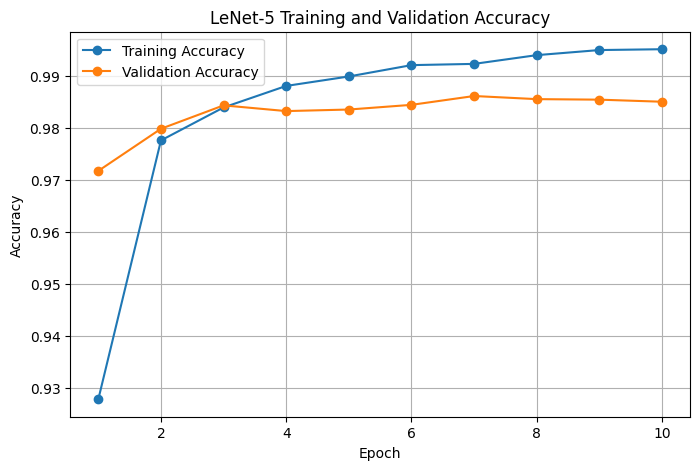

In [21]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LeNet-5 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

### Visualizing Model Predictions

Let's inspect some test images and compare:

- The actual digit
- The digit predicted by LeNet-5

This provides an intuitive view of how the model performs on individual examples.

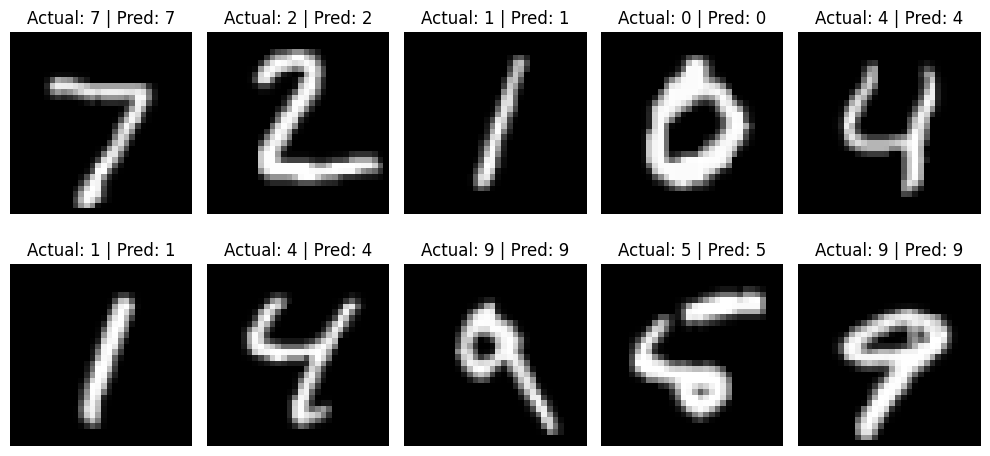

In [22]:
# Display predictions for a batch of test images

images, labels = next(iter(test_loader))

images_for_model = images.to(device)

model.eval()

with torch.no_grad():
    logits = model(images_for_model)
    predictions = logits.argmax(dim=1)

predictions = predictions.cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    # Undo normalization for visualization
    image = images[i].squeeze().numpy()
    image = image * 0.3081 + 0.1307

    ax.imshow(image, cmap="gray")

    ax.set_title(
        f"Actual: {labels[i].item()} | "
        f"Pred: {predictions[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### Confusion Matrix

A confusion matrix shows how the model classified each digit.

- Rows represent the **actual labels**
- Columns represent the **predicted labels**
- Values on the diagonal represent correct predictions
- Values outside the diagonal represent classification errors

For a well-performing model, most of the values should be concentrated along the diagonal.

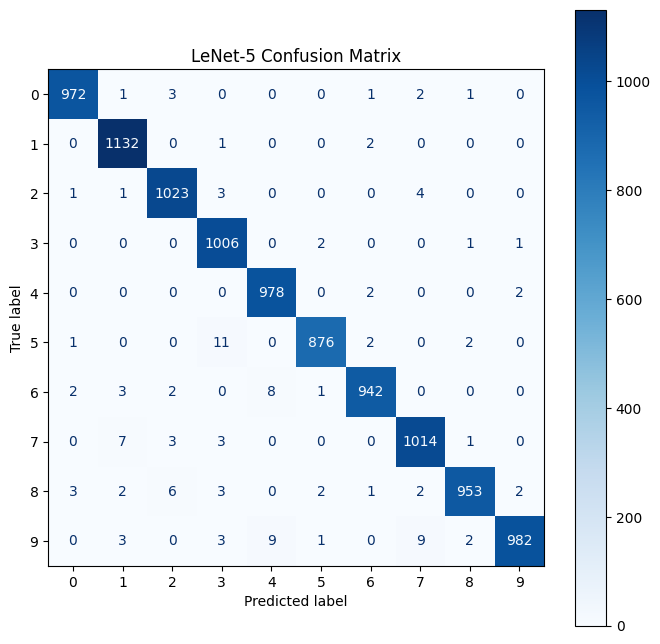

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

# Display confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("LeNet-5 Confusion Matrix")
plt.show()

### Inspecting Incorrect Predictions

Even with high accuracy, the model will make some mistakes.

Let's find a few incorrectly classified images and examine them.

This helps us understand which handwritten digits can be difficult for the model to distinguish.

In [24]:
# Find indices where predictions are incorrect

incorrect_indices = np.where(
    all_predictions != all_labels
)[0]

print("Incorrect predictions:", len(incorrect_indices))
print("Incorrect percentage:",
      len(incorrect_indices) / len(all_labels) * 100)

Incorrect predictions: 122
Incorrect percentage: 1.22


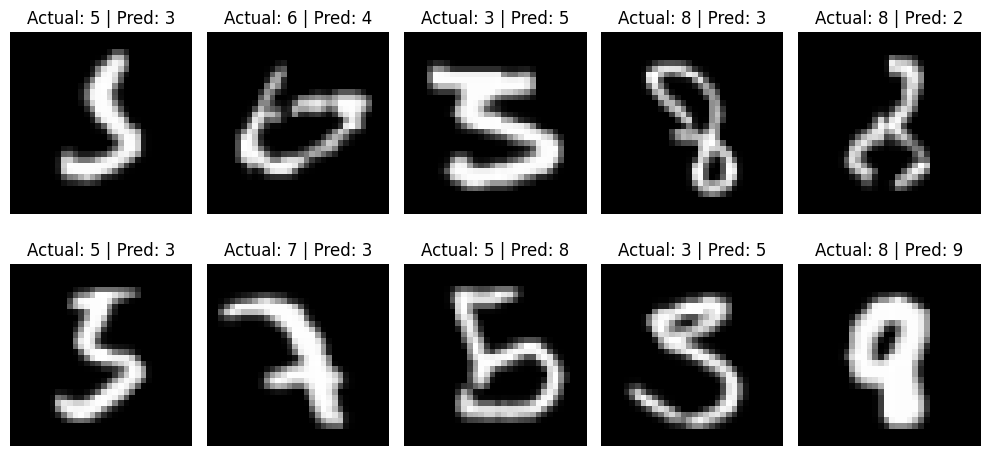

In [25]:
# Display some incorrectly classified images

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    index = incorrect_indices[i]

    image, label = test_data[index]

    # Undo normalization
    image = image.squeeze().numpy()
    image = image * 0.3081 + 0.1307

    prediction = all_predictions[index]

    ax.imshow(image, cmap="gray")

    ax.set_title(
        f"Actual: {label} | Pred: {prediction}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### Saving the Trained Model

After training and evaluation, we can save the learned model parameters.

Saving the model allows us to reuse the trained network later without training it again.

In [26]:
# Save the trained model weights

torch.save(
    model.state_dict(),
    "model_lenet5.pth"
)

print("Model saved successfully as model_lenet5.pth")

Model saved successfully as model_lenet5.pth


## 11. What We Learned

In this notebook, we implemented and studied a LeNet-5-inspired Convolutional Neural Network using PyTorch.

### Key Takeaways

- LeNet-5 is one of the foundational CNN architectures.
- Convolutional layers learn spatial features from images.
- Pooling layers reduce the spatial dimensions of feature maps.
- `Tanh` introduces non-linearity into the network.
- Flattening converts feature maps into a vector for classification.
- Fully connected layers perform the final classification.
- `CrossEntropyLoss` is suitable for multi-class classification.
- Backpropagation calculates gradients used to update model parameters.
- The Adam optimizer updates the model weights during training.
- Validation data helps monitor generalization during training.
- The test dataset provides a final evaluation on unseen data.
- A confusion matrix helps identify which classes are difficult to distinguish.

### LeNet-5 Architecture

```text
Input
  ↓
C1: Conv2D
  ↓
S2: Average Pooling
  ↓
C3: Conv2D
  ↓
S4: Average Pooling
  ↓
C5: Fully Connected
  ↓
F6: Fully Connected
  ↓
Output: 10 Classes